# Camera-pose alignment spike: tie-point correction for the real-WAC overlay

`image_generation.ipynb`'s Phase 6B overlay (the real, ISIS-processed WAC crop mapprojected onto
the basemap) is visibly not perfectly aligned with it -- small, "not huge" per direct user
observation, but real. This notebook is the checked-in, reproducible form of the investigation
into that (see `docs/plan.md`'s open items, "camera-pose alignment", for the full research trail:
why ASP's `bundle_adjust`/`pc_align`/`image_align` and ISIS's own `jigsaw`+`findfeatures` routes
both hit real blockers, and `docs/history.md`'s dated entries for how this notebook's own approach
was arrived at). **Validated, but not wired into the main pipeline** -- direct user visual
inspection of the homography-corrected blink overlay below confirmed the correspondences this
notebook finds are real, not RANSAC accepting noise (see `docs/history.md`'s dated entries),
concluded as the deliberate stopping point for this 2D approach; the next real step is a proper
projection-informed (camera-model) alignment, not further refinement here, so this stays a
standalone tool, not wired into `image_generation.py`'s main pipeline.

The approach, implemented in `src/trntest/pose_alignment.py`: feature-match the already
map-projected WAC crop directly against the basemap (both already in the same map projection, no
camera model needed for the matching step itself; downsampled first to the WAC crop's own real
native resolution -- see the "Crop the basemap" section below, and `docs/history.md`'s Phase 53
entry for why), fit a 2D correction from the matches via RANSAC, apply it to the WAC raster's own
georeferencing, and compare the result against the basemap via the *existing*, unmodified
`plotting.plot_overlay_toggle` blink comparator.

Three correction models are fit from the same match set and compared directly: `fit_similarity_correction`
(translation + rotation + uniform scale, 4 DOF), `fit_affine_correction` (adds independent x/y
scale and shear, 6 DOF), and `fit_homography_correction` (full projective, 8 DOF). None is
asserted as physically "correct" -- a real camera pose error has 6 degrees of freedom before even
accounting for this being a pushframe sensor's extended-exposure capture, and the mapping from
those onto a 2D map-space distortion isn't simple or one-to-one, so there's no first-principles
case that any fixed DOF count is exactly right; richer models were left for later specifically
until there were enough well-distributed inliers to support them without overfitting (Phase 53's
downsampling fix raised that count from 53 to 91). See `fit_similarity_correction`'s own docstring
for the full rationale.

In [1]:
import numpy as np
import rasterio

import trntest
from trntest import isis_wac, plotting, pose_alignment

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()
dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
dataset.populate(limit=1)
entry = dataset[0]

# The real public function TrnTestCropImage._mapprojected_path() itself calls -- used directly here
# rather than that private method, which isn't meant for callers outside the class.
wac_path = isis_wac.run_cam2map_for_crop(entry.crop_result, entry.dem_ortho_result, entry.per_image_config)
basemap_path = entry.dem_ortho_result.ortho
print("WAC mapprojected crop:", wac_path)
print("Basemap ortho:", basemap_path)

ROI center (lon,lat deg): (np.float64(177.77322916901), np.float64(73.50941814294002)), bbox (local m): (-141552.7461341037, -141794.26867026222, 155206.3054434107, 156570.0627159628)
ROI size 2968x2984 px (~100.0 m/px)


WAC mapprojected crop: /workspace/scratch/isis_wac/M1327210646CE/M1327210646CE.vis.cal.stitched.crop-cam2map.tif
Basemap ortho: /workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded_hapke_atc.tif


## Crop the basemap to the WAC's own footprint, and prepare both for matching

The basemap ortho covers a much larger area than the WAC crop's own real footprint -- cropping to
match (`pose_alignment.crop_to_footprint`, padded 15%) gives the feature matcher a far smaller,
more relevant search space; confirmed empirically to matter for match quality, not just compute.

Both `wac_path` and the basemap ortho are on the same ~100 m/px working grid (`config.
DEFAULT_DEM_TARGET_GSD_M`) -- but that's genuinely native resolution for the basemap
(`luna_wac_global`'s own ~100 m/px mosaic) and *not* for this WAC crop: `isis_wac.
run_cam2map_for_crop`'s `PIXRES=map` forces its output onto that same 100 m/px grid regardless of
the camera's own real resolution at this pose, which a direct `cam2map PIXRES=camera` probe found
to be ~184 m/px for this candidate (~1.8x coarser -- see `docs/history.md`'s dated entry). Matching
SIFT keypoints on the interpolated-not-actually-resolved 100 m/px grid risks treating resampling
texture (and the `PATCHSIZE=1` warp-patch seam artifact still faintly visible there, per
`docs/plan.md`'s open items) as real structure. `pose_alignment.native_wac_gsd_m` estimates the
WAC crop's real native GSD from the camera's own already-computed ground geometry (no extra ISIS
call), and `downsample_to_gsd` (area-averaging, the correct decimation filter -- see its own
docstring for why nearest/bilinear would be wrong here) brings both rasters down to that scale
before matching. `to_uint8_for_matching` then converts each to 8-bit (OpenCV's feature detectors
can't even load a raw float32 GeoTIFF), stretching over valid pixels only.

In [2]:
basemap_cropped_path = pose_alignment.crop_to_footprint(
    basemap_path, wac_path, entry.per_image_config.output_dir / "alignment" / "basemap_cropped.tif"
)

target_gsd_m = pose_alignment.native_wac_gsd_m(entry.camera)
print(f"Downsampling to the WAC crop's estimated native resolution: {target_gsd_m:.0f} m/px")
wac_matching_path = pose_alignment.downsample_to_gsd(
    wac_path, target_gsd_m, entry.per_image_config.output_dir / "alignment" / "wac_matching_res.tif"
)
basemap_matching_path = pose_alignment.downsample_to_gsd(
    basemap_cropped_path, target_gsd_m, entry.per_image_config.output_dir / "alignment" / "basemap_matching_res.tif"
)

wac_image, wac_valid = pose_alignment.to_uint8_for_matching(wac_matching_path)
basemap_image, basemap_valid = pose_alignment.to_uint8_for_matching(basemap_matching_path)
print(f"WAC: {wac_image.shape}, valid {wac_valid.mean():.1%}")
print(f"Basemap: {basemap_image.shape}, valid {basemap_valid.mean():.1%}")

Downsampling to the WAC crop's estimated native resolution: 211 m/px


WAC: (870, 809), valid 71.6%
Basemap: (988, 997), valid 100.0%


## Feature matching

SIFT on Sobel-filtered versions of each image (see `pose_alignment.match_features`'s docstring for
why: raw-intensity matching across two different sensors/processing pipelines -- real calibrated
WAC I/F vs. a synthetic basemap render -- is far less reliable than matching on edge/gradient
content, which is more consistent across that gap), with a mutual ratio test and two RANSAC
geometric-consistency passes (homography, then epipolar).

In [3]:
basemap_points_px, wac_points_px = pose_alignment.match_features(basemap_image, basemap_valid, wac_image, wac_valid)
print(f"{len(basemap_points_px)} matched points survived ratio/symmetry/RANSAC verification")

259 matched points survived ratio/symmetry/RANSAC verification


Converting both point sets to real map coordinates (`pose_alignment.pixel_points_to_map`) --
necessary since the WAC crop and the cropped basemap are different windows with different pixel
origins, even though they share a CRS/scale -- lets us look at the real-world offset each match
implies. High scatter here (relative to the mean) is a sign the match set is a mix of real
correspondences and false positives, not a single clean, trustworthy correction on its own.

In [4]:
with rasterio.open(basemap_matching_path) as src:
    basemap_transform = src.transform
with rasterio.open(wac_matching_path) as src:
    wac_transform = src.transform

basemap_points_map = pose_alignment.pixel_points_to_map(basemap_points_px, basemap_transform)
wac_points_map = pose_alignment.pixel_points_to_map(wac_points_px, wac_transform)

raw_offsets_m = wac_points_map - basemap_points_map
raw_distances_m = np.linalg.norm(raw_offsets_m, axis=1)
print(f"Raw offset distance: mean {raw_distances_m.mean():.0f}m, std {raw_distances_m.std():.0f}m")
print(f"Range: {raw_distances_m.min():.0f}m - {raw_distances_m.max():.0f}m")

Raw offset distance: mean 849m, std 350m
Range: 56m - 1607m


## Fit the pose correction: similarity, full affine, and homography

`fit_similarity_correction` maps the WAC's own (possibly-wrong) claimed positions onto the
basemap's trusted ones, with its own internal RANSAC separating real, consistent correspondences
from outliers -- report both, not just the inliers, since how bad the rejected points really are
is itself useful information about match-set quality.

Phase 53's native-resolution downsampling raised the default candidate's inlier count from 53 to
91 -- enough to make a first real attempt at the richer models `fit_similarity_correction`'s own
docstring always left open: `fit_affine_correction` (6 DOF: independent x/y scale and shear, not
just uniform scale) and `fit_homography_correction` (8 DOF: full projective). All three are fit
from the *same* match set below for a direct, apples-to-apples comparison -- residuals are also
reported in native WAC pixels (dividing by `target_gsd_m`), not just meters, since that's the unit
that actually says whether a correction is doing better than pixel-level noise.

In [5]:
correction_similarity, inliers_similarity, residuals_similarity_m = pose_alignment.fit_similarity_correction(
    wac_points_map, basemap_points_map
)
correction_affine, inliers_affine, residuals_affine_m = pose_alignment.fit_affine_correction(
    wac_points_map, basemap_points_map
)
homography, inliers_homography, residuals_homography_m = pose_alignment.fit_homography_correction(
    wac_points_map, basemap_points_map
)

for name, inliers, residuals_m in [
    ("similarity (4 DOF)", inliers_similarity, residuals_similarity_m),
    ("affine (6 DOF)", inliers_affine, residuals_affine_m),
    ("homography (8 DOF)", inliers_homography, residuals_homography_m),
]:
    inlier_residuals_m = residuals_m[inliers]
    print(
        f"{name:20s}  inliers {inliers.sum():3d}/{len(inliers)}   "
        f"residual mean {inlier_residuals_m.mean():5.0f}m ({inlier_residuals_m.mean() / target_gsd_m:.2f}px)   "
        f"max {inlier_residuals_m.max():5.0f}m ({inlier_residuals_m.max() / target_gsd_m:.2f}px)"
    )

scale = np.sqrt(correction_similarity.a**2 + correction_similarity.d**2)
rotation_deg = np.degrees(np.arctan2(correction_similarity.d, correction_similarity.a))
print(
    f"\nSimilarity fit: scale {scale:.4f}  rotation {rotation_deg:.3f} deg  "
    f"translation ({correction_similarity.c:.1f}, {correction_similarity.f:.1f}) m"
)

similarity (4 DOF)    inliers  91/259   residual mean   177m (0.84px)   max   343m (1.63px)
affine (6 DOF)        inliers 178/259   residual mean   143m (0.68px)   max   367m (1.74px)
homography (8 DOF)    inliers 189/259   residual mean   146m (0.69px)   max   298m (1.41px)

Similarity fit: scale 0.9921  rotation 0.408 deg  translation (-161.4, -364.5) m


## Apply each correction and compare via the existing blink overlay

`apply_correction` composes an `affine.Affine` fit (similarity or full affine -- both are affine,
so it handles either identically) with the WAC raster's own georeferencing and resamples back onto
its original grid; `apply_homography_correction` does the projective equivalent for the homography
fit (see its own docstring for why a homography needs a different code path). All three corrected
rasters drop straight into the *existing* `plotting.plot_overlay_toggle` blink comparator with no
further plumbing changes. A blink comparator is the right tool for judging a shift this small (a
few pixels): far more sensitive than a static side-by-side crop.

In [6]:
alignment_dir = entry.per_image_config.output_dir / "alignment"
corrected_similarity_path = pose_alignment.apply_correction(
    wac_path, correction_similarity, alignment_dir / "wac_corrected_similarity.tif"
)
corrected_affine_path = pose_alignment.apply_correction(
    wac_path, correction_affine, alignment_dir / "wac_corrected_affine.tif"
)
corrected_homography_path = pose_alignment.apply_homography_correction(
    wac_path, homography, alignment_dir / "wac_corrected_homography.tif"
)


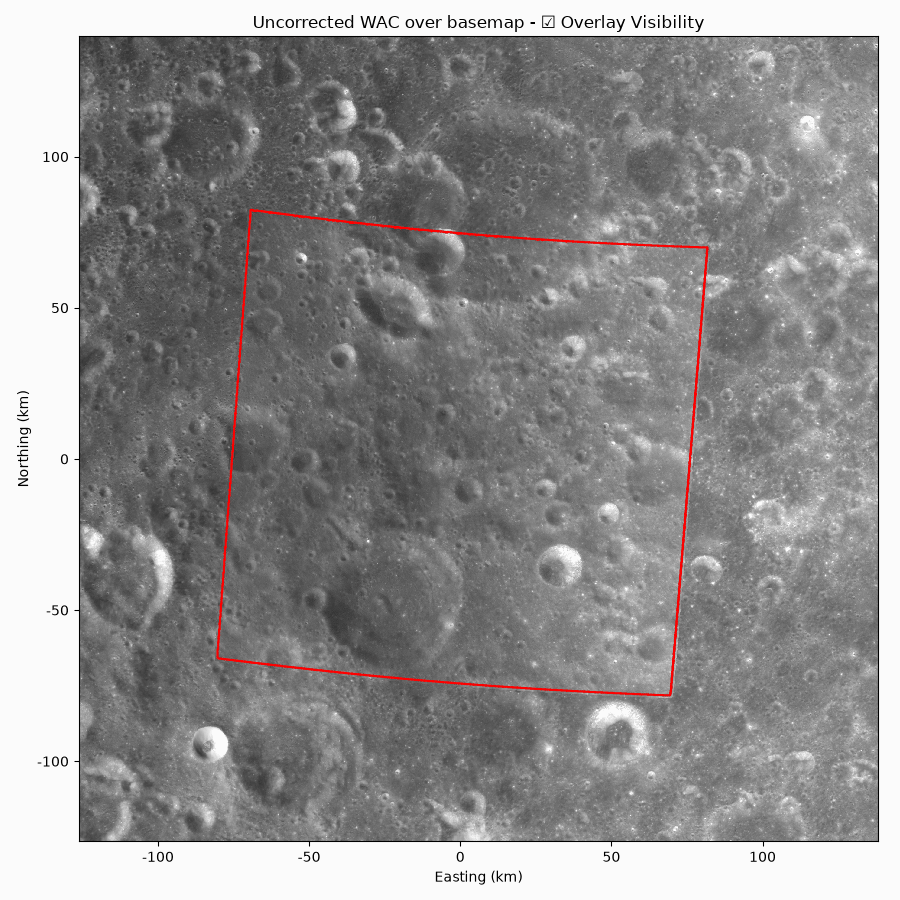

In [7]:
plotting.plot_overlay_toggle(basemap_path, wac_path, title="Uncorrected WAC over basemap")


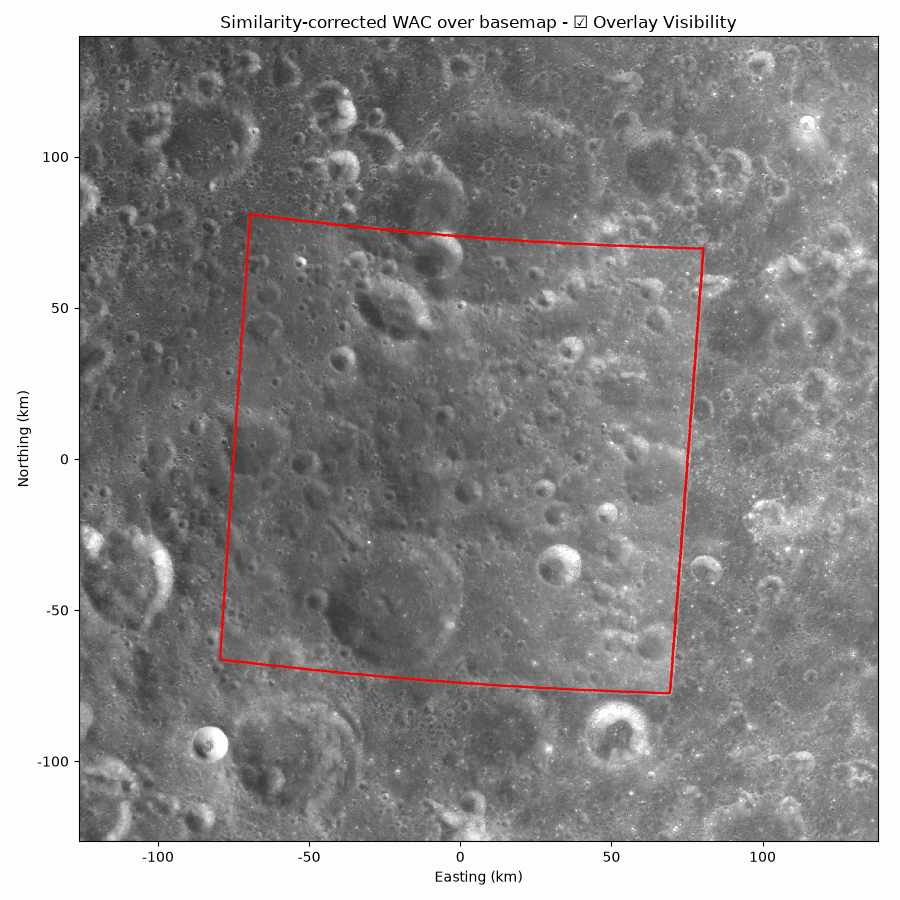

In [8]:
plotting.plot_overlay_toggle(basemap_path, corrected_similarity_path, title="Similarity-corrected WAC over basemap")


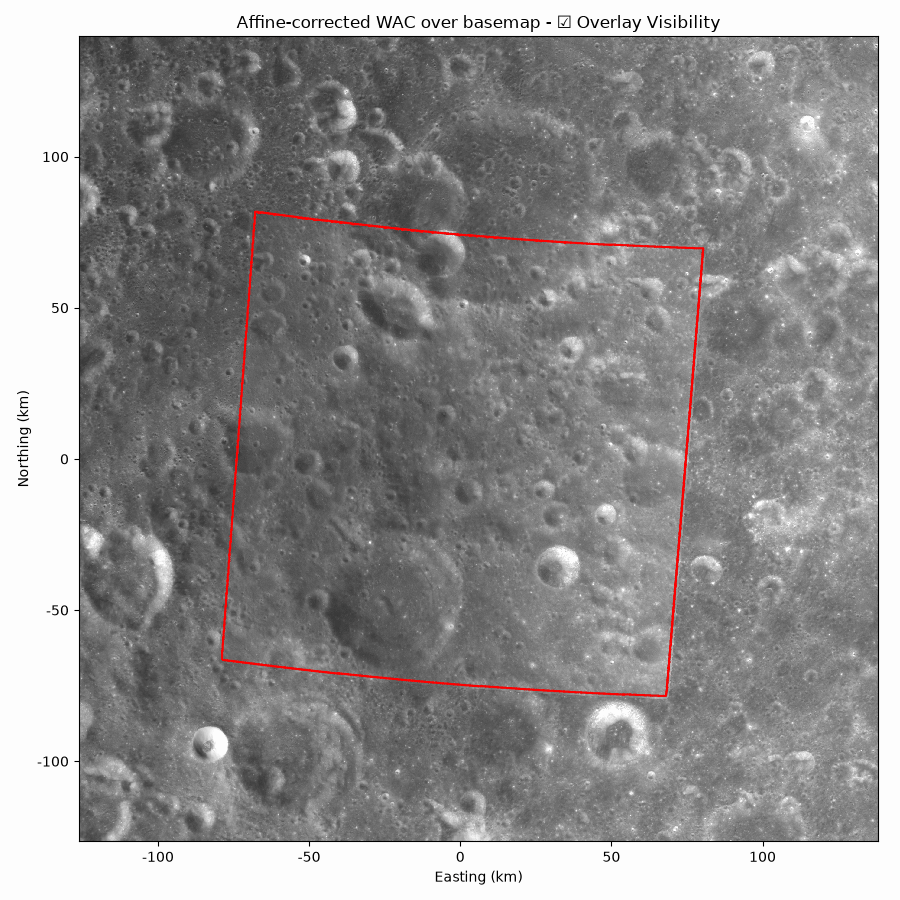

In [9]:
plotting.plot_overlay_toggle(basemap_path, corrected_affine_path, title="Affine-corrected WAC over basemap")


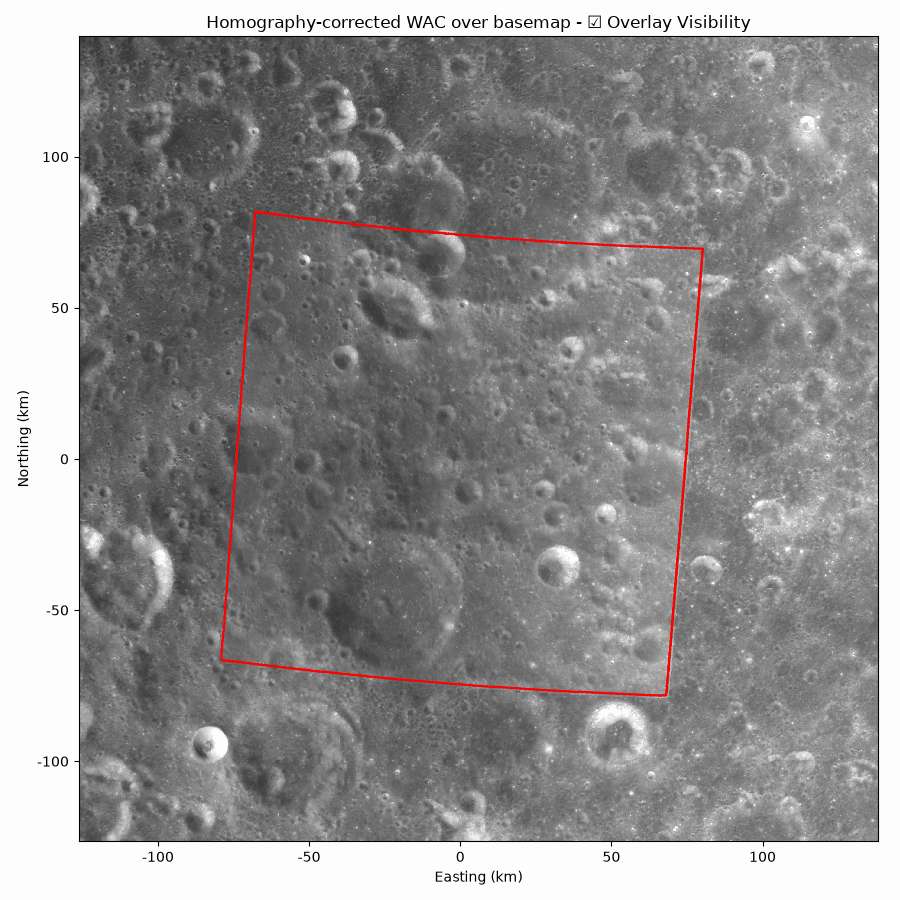

In [10]:
plotting.plot_overlay_toggle(basemap_path, corrected_homography_path, title="Homography-corrected WAC over basemap")

## A second matcher: LightGlue, compared directly against SIFT

`pose_alignment.match_features_lightglue` swaps classical SIFT for a deep-learned local-feature
extractor (DISK) + learned matcher (LightGlue) -- tried specifically to push match count/quality
higher for more challenging future EDRs (shadowed terrain, low texture) than SIFT can reliably
deliver. Same inputs (the native-GSD-downsampled `wac_image`/`basemap_image` from above), same
downstream pipeline (map coordinates -> `fit_homography_correction`, the model Phase 54's direct
user visual inspection validated as giving a real, non-noise improvement) -- only the matcher
itself differs, for a direct, apples-to-apples comparison against the SIFT-based homography result
already shown above.

In [11]:
basemap_points_px_lg, wac_points_px_lg = pose_alignment.match_features_lightglue(
    basemap_image, basemap_valid, wac_image, wac_valid
)
print(f"SIFT:      {len(basemap_points_px)} matched points")
print(f"LightGlue: {len(basemap_points_px_lg)} matched points")

basemap_points_map_lg = pose_alignment.pixel_points_to_map(basemap_points_px_lg, basemap_transform)
wac_points_map_lg = pose_alignment.pixel_points_to_map(wac_points_px_lg, wac_transform)

homography_lg, inliers_homography_lg, residuals_homography_lg_m = pose_alignment.fit_homography_correction(
    wac_points_map_lg, basemap_points_map_lg
)
inlier_residuals_lg_m = residuals_homography_lg_m[inliers_homography_lg]
print(
    f"\nSIFT homography:      inliers {inliers_homography.sum():3d}/{len(inliers_homography)}   "
    f"residual mean {residuals_homography_m[inliers_homography].mean():5.0f}m "
    f"({residuals_homography_m[inliers_homography].mean() / target_gsd_m:.2f}px)"
)
print(
    f"LightGlue homography: inliers {inliers_homography_lg.sum():3d}/{len(inliers_homography_lg)}   "
    f"residual mean {inlier_residuals_lg_m.mean():5.0f}m ({inlier_residuals_lg_m.mean() / target_gsd_m:.2f}px)"
)

SIFT:      259 matched points
LightGlue: 767 matched points

SIFT homography:      inliers 189/259   residual mean   146m (0.69px)
LightGlue homography: inliers 573/767   residual mean   164m (0.78px)



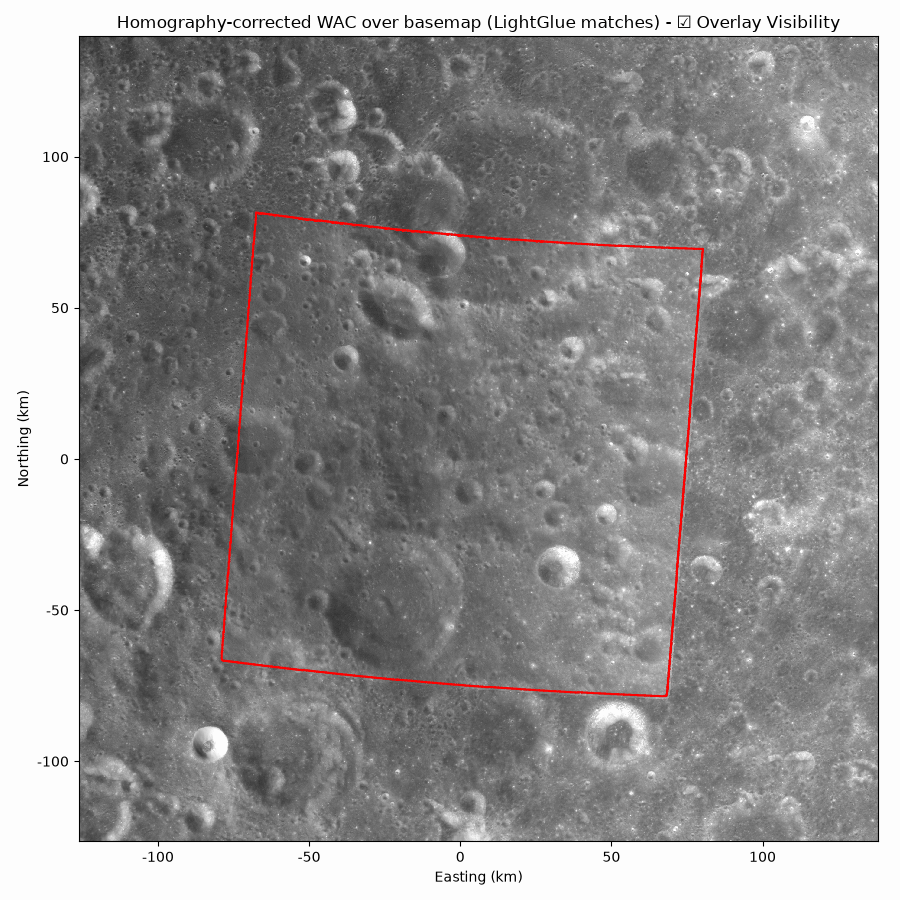

In [12]:
corrected_homography_lg_path = pose_alignment.apply_homography_correction(
    wac_path, homography_lg, alignment_dir / "wac_corrected_homography_lightglue.tif"
)
plotting.plot_overlay_toggle(
    basemap_path, corrected_homography_lg_path, title="Homography-corrected WAC over basemap (LightGlue matches)"
)